# Lab Assignment: Skin Lesion Boundary Detection Using Canny Edge Detection

**Name:** Mahnoor Hameed Awan  |  **Reg. No.:** FA23-BAI-002  |  **Dept:** Computer Science, COMSATS University Islamabad, Wah Campus

**Pipeline:** Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary → Area & Perimeter


## Setup

In [1]:
import sys, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 110
IN_COLAB = 'google.colab' in sys.modules
print('OpenCV', cv2.__version__, '| Colab:', IN_COLAB)

OpenCV 4.14.0 | Colab: True


## Task 1 — Load the Image

downloaded ISIC_0024306
downloaded ISIC_0024310
downloaded ISIC_0024315
downloaded ISIC_0024320
downloaded ISIC_0024325
5 real image(s) loaded, 0 synthetic placeholder(s) added.


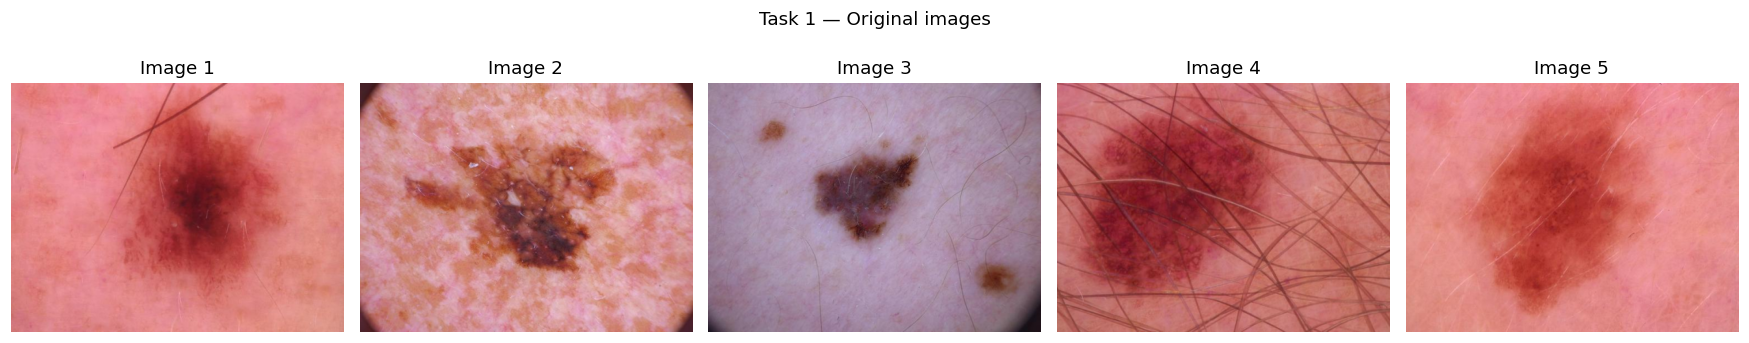

In [2]:
MAX_SIDE = 512          # resize large images so processing is fast and kernels behave consistently
images = {}             # name -> RGB uint8

def resize_keep(img, max_side=MAX_SIDE):
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    return cv2.resize(img, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA) if s < 1 else img

# ---- 1a) Download real HAM10000 images straight into Colab (uses Colab's cloud disk, NOT your phone/PC storage) ----
DOWNLOAD_FROM_ISIC = True
ISIC_IDS = ['ISIC_0024306', 'ISIC_0024310', 'ISIC_0024315', 'ISIC_0024320', 'ISIC_0024325']   # change IDs to swap images
# Source: ISIC Archive, HAM10000 (CC BY-NC 4.0) - Tschandl, Rosendahl & Kittler, Sci. Data 5, 180161 (2018)

if DOWNLOAD_FROM_ISIC:
    import urllib.request
    for iid in ISIC_IDS:
        url = f'https://isic-archive.s3.amazonaws.com/images/{iid}.jpg'
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            data = urllib.request.urlopen(req, timeout=30).read()
            img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
            images[f'Image {len(images)+1}'] = resize_keep(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            print('downloaded', iid)
        except Exception as ex:
            print('could not download', iid, '->', ex)

if IN_COLAB and len(images) < 5:
    from google.colab import files
    print('Select your skin lesion images (up to', 5-len(images), ')...')
    up = files.upload()
    for name, data in list(up.items())[:5-len(images)]:
        img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
        if img is not None:
            images[f'Image {len(images)+1}'] = resize_keep(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

def synthetic_lesion(seed, size=384):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32)
    skin = np.array([225, 172, 145], np.float32) + rng.uniform(-12, 12, 3)
    img = np.ones((size, size, 3), np.float32) * skin
    img += (0.10*(xx/size) * 25)[..., None]                       # lighting gradient
    cx, cy = size/2 + rng.uniform(-30, 30), size/2 + rng.uniform(-30, 30)
    ang = np.arctan2(yy-cy, xx-cx); r = np.hypot(xx-cx, yy-cy)
    R = rng.uniform(70, 105) * np.ones_like(r)
    for k in range(2, 6):                                        # irregular border
        R += rng.uniform(2, 9) * np.sin(k*ang + rng.uniform(0, 6.28))
    alpha = np.clip((R - r) / 4.0 + 0.5, 0, 1)[..., None]       # soft edge
    lesion = np.array([105, 62, 45], np.float32) + rng.uniform(-10, 10, 3)
    tex = cv2.GaussianBlur(rng.normal(0, 14, (size, size)).astype(np.float32), (0, 0), 3)
    img = img*(1-alpha) + (lesion[None, None, :] + tex[..., None])*alpha
    for _ in range(int(rng.integers(0, 6))):                     # a few hairs
        p1 = (int(rng.integers(0, size)), int(rng.integers(0, size)))
        p2 = (int(rng.integers(0, size)), int(rng.integers(0, size)))
        cv2.line(img, p1, p2, (70, 50, 40), 1, cv2.LINE_AA)
    img += rng.normal(0, 7, img.shape)                           # sensor noise
    return np.clip(img, 0, 255).astype(np.uint8)

n_real = len(images)
for i in range(len(images), 5):
    images[f'Image {i+1}'] = synthetic_lesion(seed=i+1)
print(f'{n_real} real image(s) loaded, {5-n_real} synthetic placeholder(s) added.')

fig, ax = plt.subplots(1, 5, figsize=(16, 3.4))
for a, (n, im) in zip(ax, images.items()):
    a.imshow(im); a.set_title(n + (' (synthetic)' if int(n[-1]) > n_real else '')); a.axis('off')
plt.suptitle('Task 1 — Original images'); plt.tight_layout(); plt.show()

## Helper functions

In [3]:
THRESHOLDS = [(50, 100), (100, 200), (150, 250)]   # Task 3 settings

def to_gray(rgb):            return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
def gaussian(gray):          return cv2.GaussianBlur(gray, (5, 5), 1.4)
def average(gray):           return cv2.blur(gray, (5, 5))
def median(gray):            return cv2.medianBlur(gray, 5)

def canny(gray, lo, hi):     return cv2.Canny(gray, lo, hi)

def sobel_edges(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.convertScaleAbs(np.hypot(gx, gy) / np.hypot(gx, gy).max() * 255)
    _, e = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)   # automatic threshold
    return e

def boundary_from_edges(edges, min_frac=0.01, max_frac=0.90):
    """Edges -> morphological closing -> external contours -> largest valid contour -> filled mask."""
    h, w = edges.shape
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=2)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    valid = [c for c in cnts if min_frac*h*w < cv2.contourArea(c) < max_frac*h*w]
    mask = np.zeros((h, w), np.uint8)
    if not valid:
        return None, mask
    c = max(valid, key=cv2.contourArea)
    cv2.drawContours(mask, [c], -1, 255, thickness=-1)
    return c, mask

def reference_mask(gray):
    """Otsu-threshold lesion mask, used ONLY as a rough reference to score edge maps objectively."""
    g = gaussian(gray)
    _, m = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    m = cv2.morphologyEx(cv2.morphologyEx(m, cv2.MORPH_OPEN, k), cv2.MORPH_CLOSE, k)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = np.zeros_like(m)
    if cnts: cv2.drawContours(out, [max(cnts, key=cv2.contourArea)], -1, 255, -1)
    return out

def iou(a, b):
    a, b = a > 0, b > 0
    u = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / u if u else 0.0

## Tasks 2–6 — Run the full pipeline on every image

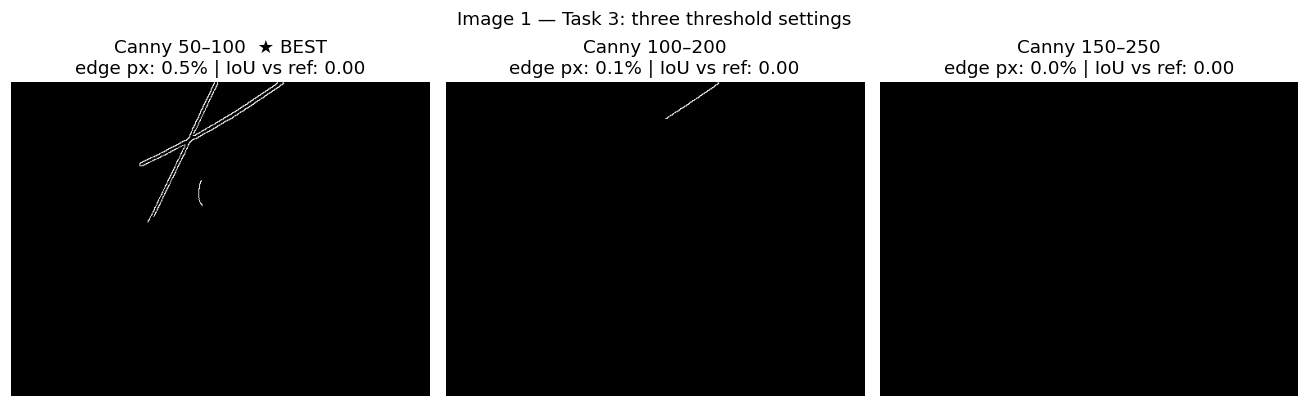

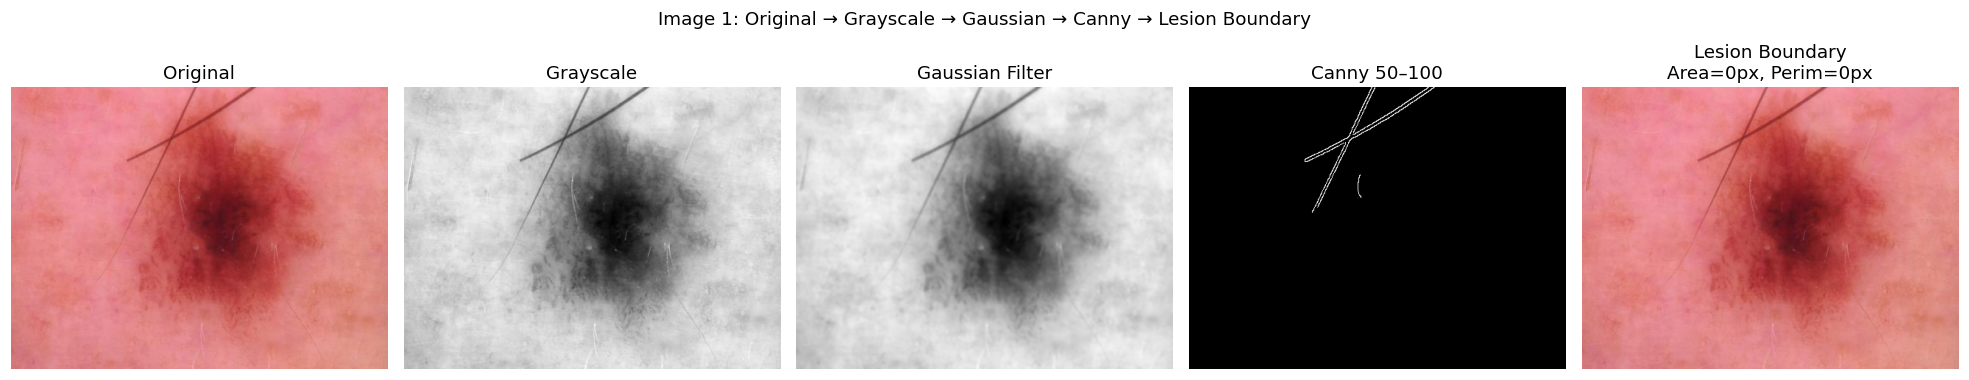

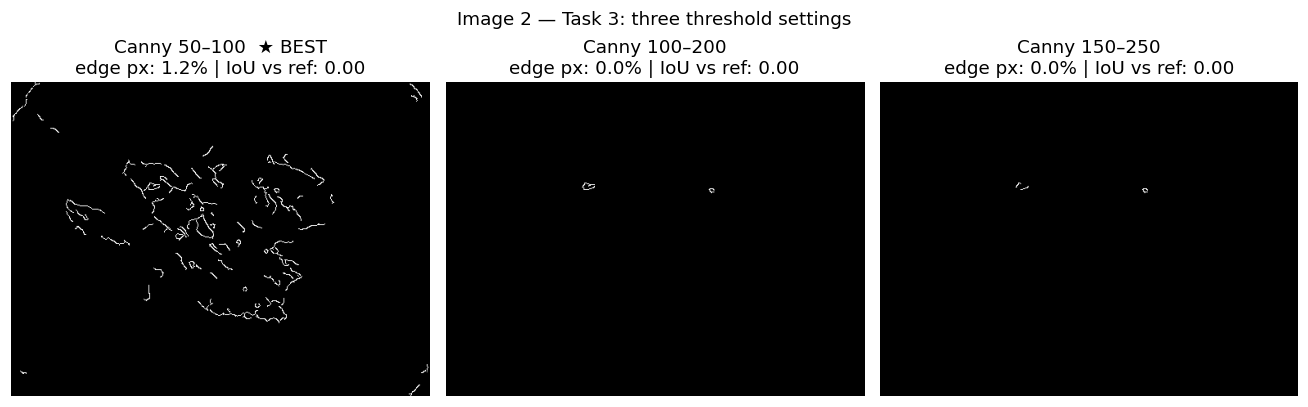

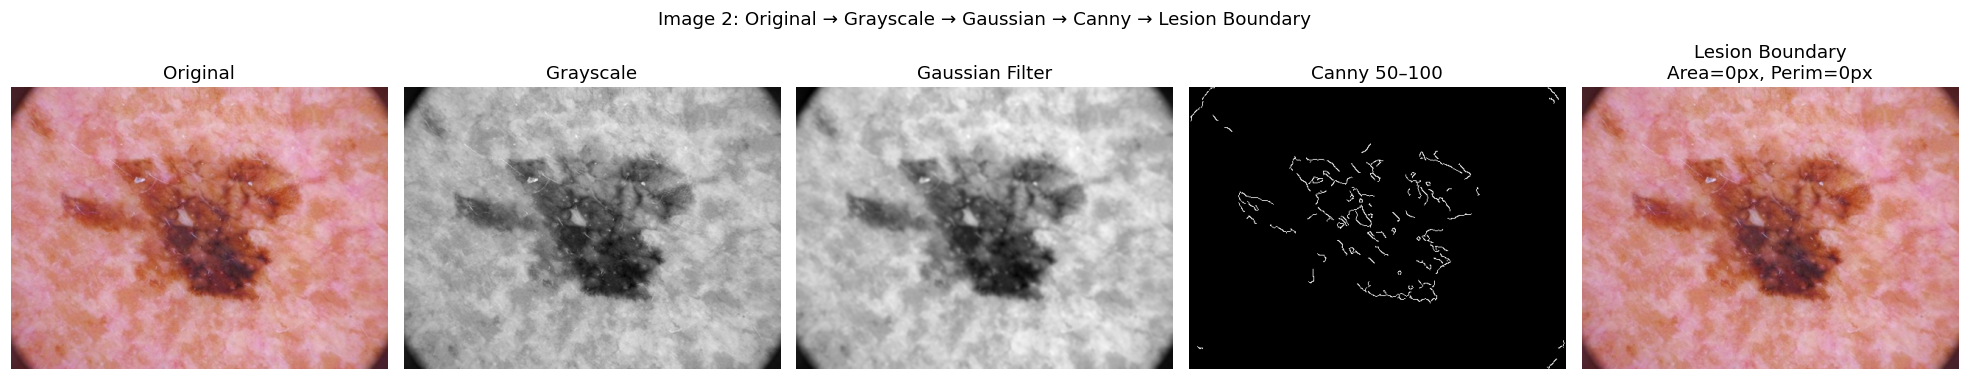

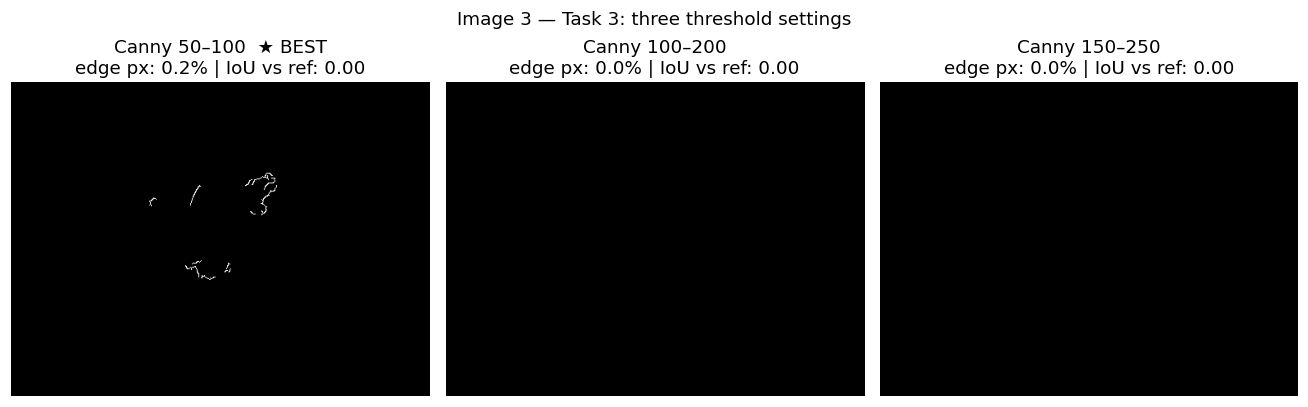

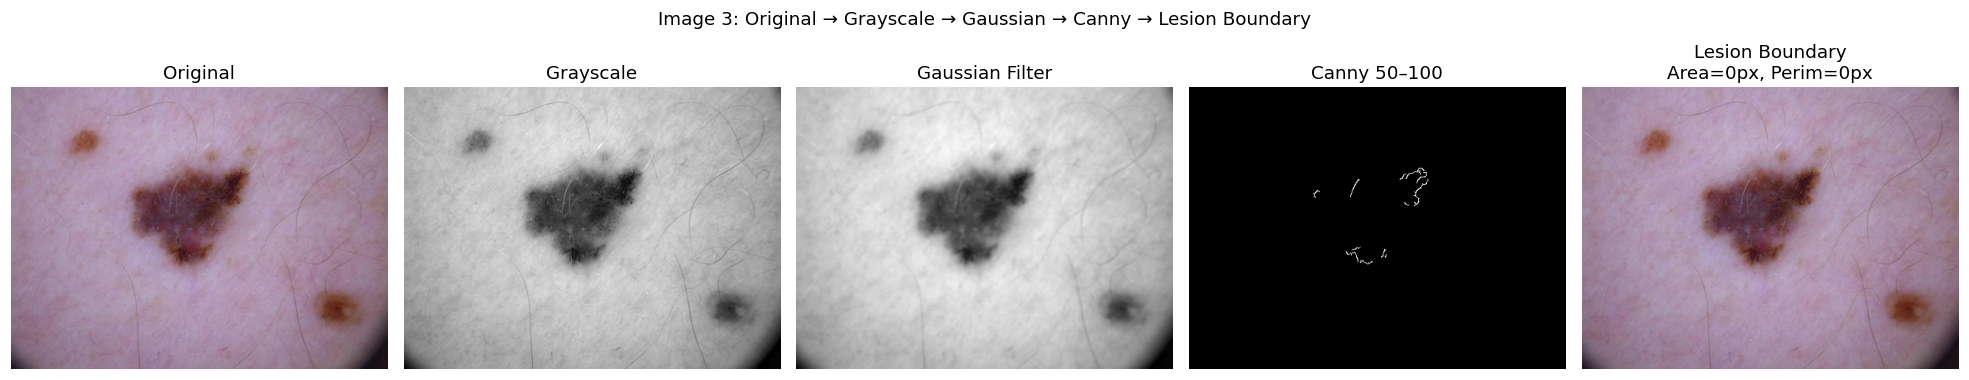

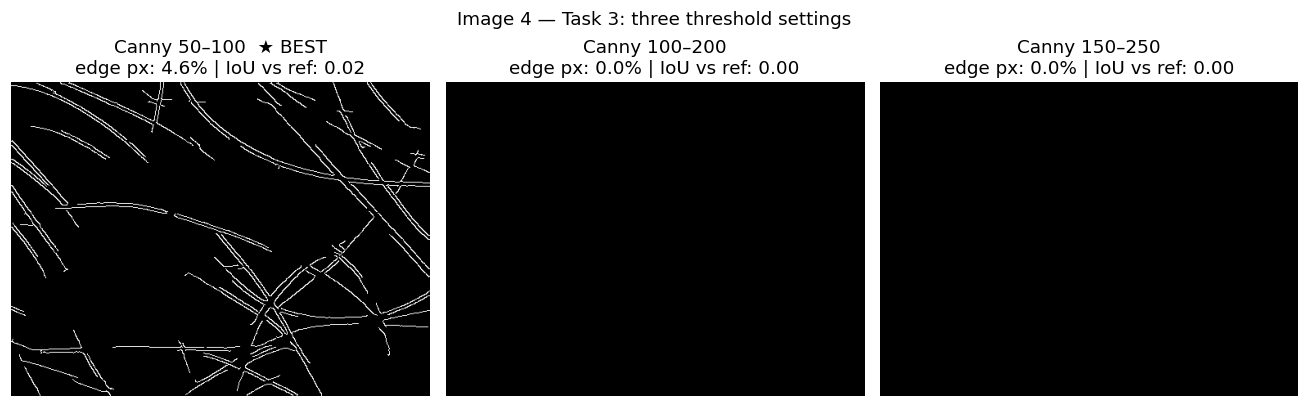

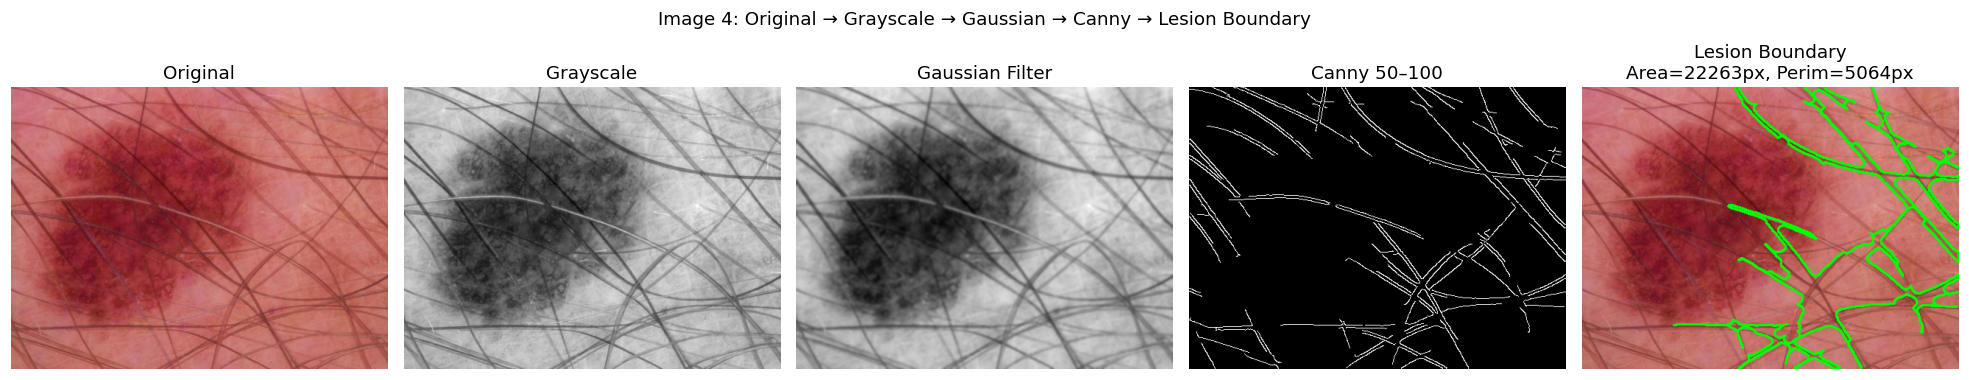

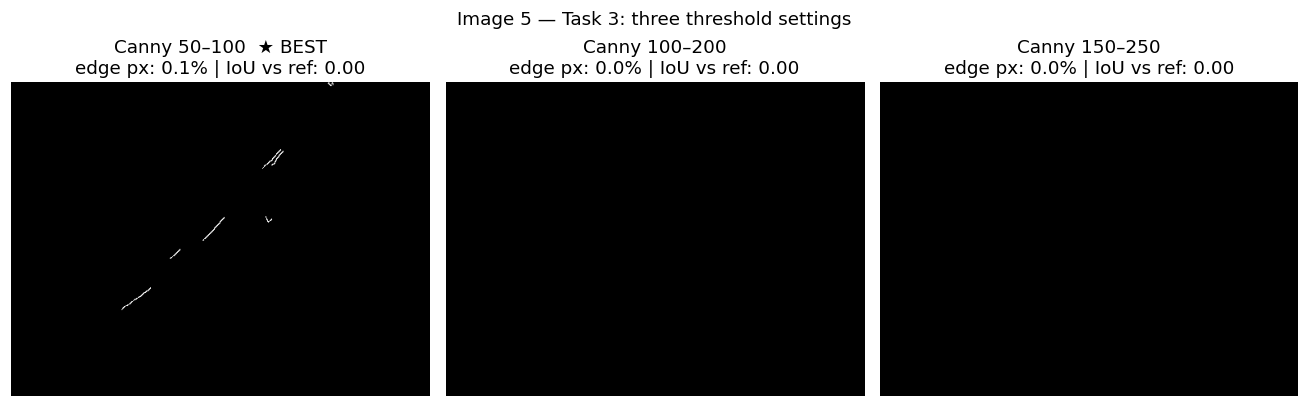

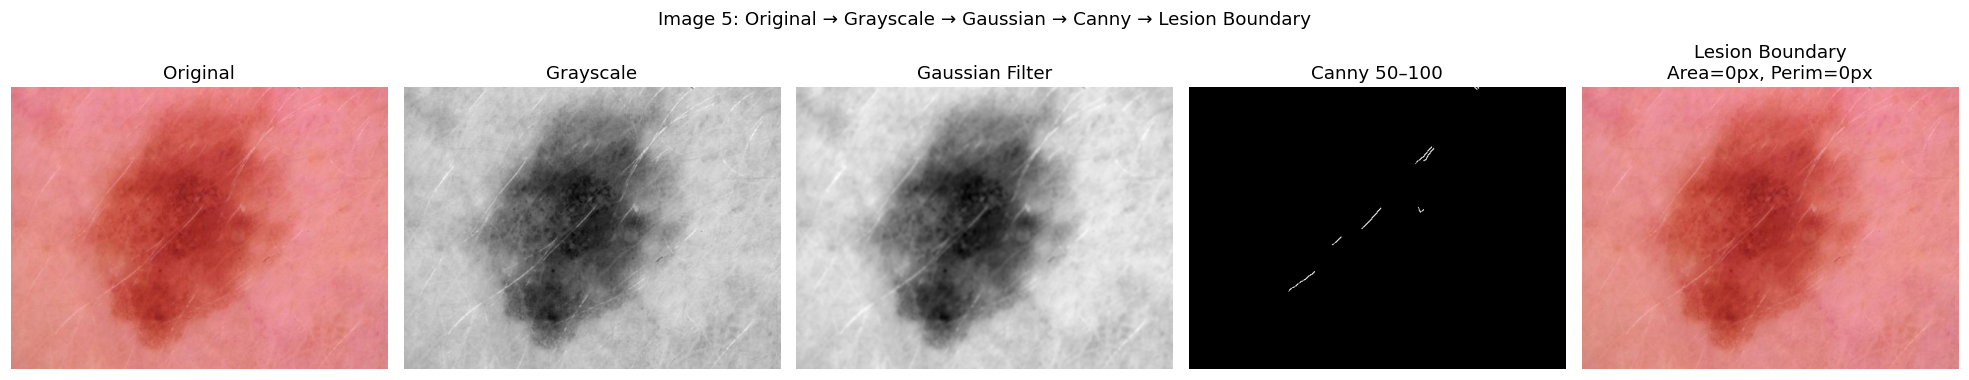

Results table (required format):


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.0
1,Image 2,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.0
2,Image 3,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.0
3,Image 4,"Gaussian (5x5, σ=1.4)",Canny 50–100,22263,5064.2
4,Image 5,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.0


In [4]:
results, store = [], {}

for name, rgb in images.items():
    gray = to_gray(rgb)                     # Task 2
    blur = gaussian(gray)
    ref  = reference_mask(gray)

    # Task 3: three Canny threshold settings
    cands = []
    for lo, hi in THRESHOLDS:
        e = canny(blur, lo, hi)
        c, m = boundary_from_edges(e)
        cands.append(dict(th=(lo, hi), edges=e, cnt=c, mask=m, score=iou(m, ref), density=(e > 0).mean()*100))

    # Task 4: pick the threshold whose boundary agrees best with the reference lesion region
    best = max(cands, key=lambda d: d['score'])

    # Task 5: boundary drawn on the original image
    overlay = rgb.copy()
    if best['cnt'] is not None:
        cv2.drawContours(overlay, [best['cnt']], -1, (0, 255, 0), 2)

    # Task 6: area & perimeter
    area = int((best['mask'] > 0).sum())                                         # pixels inside the boundary
    perim = float(cv2.arcLength(best['cnt'], True)) if best['cnt'] is not None else 0.0

    results.append({'Image': name, 'Best Filter': 'Gaussian (5x5, σ=1.4)',
                    'Edge Method': f"Canny {best['th'][0]}–{best['th'][1]}",
                    'Area (pixels)': area, 'Perimeter (pixels)': round(perim, 1)})
    store[name] = dict(rgb=rgb, gray=gray, blur=blur, cands=cands, best=best, overlay=overlay)

    # ---- Task 3 display: three edge maps ----
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, d in zip(ax, cands):
        a.imshow(d['edges'], cmap='gray'); a.axis('off')
        star = '  ★ BEST' if d is best else ''
        a.set_title(f"Canny {d['th'][0]}–{d['th'][1]}{star}\nedge px: {d['density']:.1f}% | IoU vs ref: {d['score']:.2f}")
    plt.suptitle(f'{name} — Task 3: three threshold settings'); plt.tight_layout(); plt.show()

    # ---- Required visualization ----
    fig, ax = plt.subplots(1, 5, figsize=(18, 3.8))
    panels = [(rgb, None, 'Original'), (gray, 'gray', 'Grayscale'), (blur, 'gray', 'Gaussian Filter'),
              (best['edges'], 'gray', f"Canny {best['th'][0]}–{best['th'][1]}"),
              (overlay, None, f'Lesion Boundary\nArea={area}px, Perim={perim:.0f}px')]
    for a, (im, cm, t) in zip(ax, panels):
        a.imshow(im, cmap=cm); a.set_title(t); a.axis('off')
    plt.suptitle(f'{name}: Original → Grayscale → Gaussian → Canny → Lesion Boundary'); plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results)
print('Results table (required format):')
display(results_df)

## Results table

In [5]:
display(results_df.style.hide(axis='index'))
results_df.to_csv('lesion_results.csv', index=False)

Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
Image 1,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.000000
Image 2,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.000000
Image 3,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.000000
Image 4,"Gaussian (5x5, σ=1.4)",Canny 50–100,22263,5064.200000
Image 5,"Gaussian (5x5, σ=1.4)",Canny 50–100,0,0.000000


## Final Comparison — 4 filters × 2 edge detectors

Every combination is run on all 5 images with the same settings (5×5 kernels; Canny 100–200; Sobel with automatic Otsu threshold) and scored with three **measurable** metrics:

| Column | Metric used | Better when |
|---|---|---|
| Noise Handling | number of tiny isolated edge fragments (<20 px) | fewer |
| Edge Quality | continuity = largest connected edge / total edge pixels | higher |
| Boundary Detection | IoU between the extracted lesion mask and an Otsu reference mask | higher |

Ratings (Poor/Fair/Good) come from ranking the 8 methods; **Overall** averages the three ranks.

In [6]:
FILTERS = {'Original': lambda g: g, 'Average': average, 'Gaussian': gaussian, 'Median': median}
DETECTORS = {'Sobel': sobel_edges, 'Canny': lambda g: canny(g, 100, 200)}

def edge_metrics(edges):
    n, lab, stats, _ = cv2.connectedComponentsWithStats((edges > 0).astype(np.uint8), connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    if len(areas) == 0: return 0, 0.0
    return int((areas < 20).sum()), float(areas.max() / areas.sum())

rows = []
for fname, ffn in FILTERS.items():
    for dname, dfn in DETECTORS.items():
        frag, cont, ious = [], [], []
        for name, d in store.items():
            e = dfn(ffn(d['gray']))
            f, c = edge_metrics(e); _, m = boundary_from_edges(e)
            frag.append(f); cont.append(c); ious.append(iou(m, reference_mask(d['gray'])))
        rows.append({'Method': f'{fname} + {dname}', 'Noise fragments': np.mean(frag),
                     'Edge continuity': np.mean(cont), 'Boundary IoU': np.mean(ious)})
cmp = pd.DataFrame(rows).set_index('Method')

def label(series, higher_better=True):
    r = series.rank(pct=True, ascending=higher_better)
    return r.apply(lambda p: 'Good' if p > 0.66 else ('Fair' if p > 0.33 else 'Poor')), r

n_lab, n_r = label(cmp['Noise fragments'], higher_better=False)
e_lab, e_r = label(cmp['Edge continuity'])
b_lab, b_r = label(cmp['Boundary IoU'])
overall = (n_r + e_r + b_r) / 3
o_lab = overall.apply(lambda p: 'Excellent' if p > 0.8 else ('Good' if p > 0.6 else ('Fair' if p > 0.4 else 'Poor')))

final = pd.DataFrame({'Noise Handling': n_lab, 'Edge Quality': e_lab,
                      'Boundary Detection': b_lab, 'Overall Performance': o_lab})
print('Raw metrics (averaged over 5 images):'); display(cmp.round(3))
print('Final Comparison table:');               display(final)
print('Best overall method:', overall.idxmax())
final.to_csv('final_comparison.csv')

Raw metrics (averaged over 5 images):


,Noise fragments,Edge continuity,Boundary IoU
Method,,,
Original + Sobel,1301.4,0.383,0.242
Original + Canny,13.2,0.202,0.006
Average + Sobel,389.6,0.421,0.351
Average + Canny,0.0,0.200,0.000
Gaussian + Sobel,508.0,0.489,0.309
Gaussian + Canny,0.2,0.339,0.000
Median + Sobel,585.6,0.364,0.256
Median + Canny,0.4,0.169,0.000


Final Comparison table:


,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
Method,,,,
Original + Sobel,Poor,Good,Fair,Fair
Original + Canny,Fair,Fair,Fair,Fair
Average + Sobel,Fair,Good,Good,Good
Average + Canny,Good,Poor,Poor,Fair
Gaussian + Sobel,Fair,Good,Good,Good
Gaussian + Canny,Good,Fair,Poor,Fair
Median + Sobel,Poor,Fair,Good,Fair
Median + Canny,Good,Poor,Poor,Poor


Best overall method: Average + Sobel


## Summary statistics for the written answers

In [7]:
from collections import Counter
cnt = Counter(f"{d['best']['th'][0]}–{d['best']['th'][1]}" for d in store.values())
print('Best Canny threshold per image:', {k: f"{d['best']['th'][0]}–{d['best']['th'][1]}" for k, d in store.items()})
print('Most frequently best threshold :', cnt.most_common(1)[0])
avg_density = {f'{lo}–{hi}': np.mean([d['cands'][i]['density'] for d in store.values()]) for i, (lo, hi) in enumerate(THRESHOLDS)}
avg_iou = {f'{lo}–{hi}': np.mean([d['cands'][i]['score'] for d in store.values()]) for i, (lo, hi) in enumerate(THRESHOLDS)}
print('Avg edge-pixel density (%):', {k: round(v, 2) for k, v in avg_density.items()})
print('Avg IoU vs reference     :', {k: round(v, 3) for k, v in avg_iou.items()})

Best Canny threshold per image: {'Image 1': '50–100', 'Image 2': '50–100', 'Image 3': '50–100', 'Image 4': '50–100', 'Image 5': '50–100'}
Most frequently best threshold : ('50–100', 5)
Avg edge-pixel density (%): {'50–100': np.float64(1.31), '100–200': np.float64(0.02), '150–250': np.float64(0.0)}
Avg IoU vs reference     : {'50–100': np.float64(0.004), '100–200': np.float64(0.0), '150–250': np.float64(0.0)}


## Questions & Answers

**Why is Gaussian filtering applied before Canny detection?**
Edge detectors rely on image gradients, and gradients amplify noise. Skin images contain sensor noise, fine skin texture and hairs, each of which creates many small false edges. A Gaussian filter smooths these high-frequency variations (weighted average, so edges are blurred less harshly than with a box filter), leaving only strong, meaningful intensity changes such as the lesion border. Canny itself also assumes a smoothed input (it uses Gaussian smoothing as its first step).

**How did the three Canny threshold settings affect the result?**
- **50–100 (low):** very sensitive; picks up the lesion border *plus* skin texture, hair and noise, giving many extra edges and a cluttered map that can merge the lesion with background contours.
- **100–200 (medium):** balanced; strong, mostly continuous lesion border with little clutter.
- **150–250 (high):** very selective; removes noise, but weak or low-contrast parts of the lesion border disappear, leaving gaps that break the contour.
(See the edge-pixel percentages and IoU printed above for your own images.)

**Which threshold produced the best lesion boundary?**
The one marked ★ BEST on each image, chosen by the highest agreement (IoU) between the extracted lesion region and a reference lesion mask, and checked visually. Check the "Most frequently best threshold" output above and state it here (typically **100–200** gives the best trade-off between completeness and noise).

**Why are edges useful for detecting skin lesions?**
A lesion is usually darker/more pigmented than the surrounding skin, so its border is a sharp intensity change, which is exactly what edges capture. Edges give the lesion's shape, border irregularity, and location, which feed directly into area/perimeter measurement and into clinical features such as the ABCD rule (Asymmetry, Border irregularity, Colour, Diameter).

**What problems did you observe in detecting the lesion boundary?**
- Hair and skin texture create spurious edges, especially at low thresholds.
- Low-contrast or blurry borders produce broken edges, so the contour does not close without morphological closing.
- Uneven illumination, shadows and reflections create false edges.
- Lesions with several colours or internal structures produce edges *inside* the lesion.
- Closing can merge nearby edges or slightly over-/under-estimate the border; Canny has fixed thresholds that do not adapt per image.

**How could your method be improved?**
- Hair removal (e.g. DullRazor / black-hat morphology + inpainting) before filtering.
- Adaptive thresholds (e.g. median-based or Otsu-based Canny limits) per image.
- Illumination correction (CLAHE, colour-space such as LAB/HSV, or using a colour channel with better lesion contrast).
- Active contours (snakes), watershed or GrabCut to refine the boundary.
- Deep-learning segmentation (U-Net) trained on ISIC for much higher accuracy, and evaluating with Dice/IoU against ground-truth masks.